In [1]:

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import xarray as xr
import xesmf as xe

import mcs_prime.mcs_prime_config_util as cu

DATADIR = cu.PATHS['datadir']

In [2]:
n216ds = xr.open_dataset('/gws/nopw/j04/mcs_prime/mmuetz/data/UM_sims/u-dg135/share/cycle/20200701T0000Z/engl/um/em0/englaa_pa000.iris.nc')


In [3]:
IMERG_FINAL_30MIN_DIR = DATADIR / 'GPM_IMERG_final/30min'

t = pd.Timestamp(2020, 7, 1)
def h_to_m(h):
    return h * 60

imerg_path = (
    IMERG_FINAL_30MIN_DIR /
    f'{t.year}/{t.month:02d}/{t.day:02d}/' /
    f'3B-HHR.MS.MRG.3IMERG.{t.year}{t.month:02d}{t.day:02d}-S{t.hour:02d}0000-E{t.hour:02d}2959.{h_to_m(t.hour):04d}.V07B.HDF5.nc4'
)
imerg_path.exists()

True

In [4]:
imerg = xr.open_dataset(imerg_path)

In [5]:
imerg

<xarray.Dataset>
Dimensions:        (time: 1, lon: 3600, lat: 1800)
Coordinates:
  * lat            (lat) float32 -89.95 -89.85 -89.75 ... 89.75 89.85 89.95
  * lon            (lon) float32 -179.9 -179.9 -179.8 ... 179.8 179.8 179.9
  * time           (time) object 2020-07-01 00:00:00
Data variables:
    precipitation  (time, lon, lat) float32 ...
Attributes:
    FileHeader:                      DOI=10.5067/GPM/IMERG/3B-HH/07;\nDOIauth...
    FileInfo:                        DataFormatVersion=7e;\nTKCodeBuildVersio...
    Grid.GridHeader:                 BinMethod=ARITHMETIC_MEAN;\nRegistration...
    Grid.fullnamepath:               /Grid
    DODS_EXTRA.Unlimited_Dimension:  time
    history:                         2024-06-06 14:57:30 GMT Hyrax-1.16.3 htt...

In [6]:
imerg_bounds = imerg.cf.add_bounds(['lat', 'lon'])

In [7]:
n216ds_bounds = n216ds.cf.add_bounds(['latitude', 'longitude']).drop_dims(['latitude_0', 'longitude_0'])

In [8]:
regridder = xe.Regridder(imerg_bounds, n216ds_bounds, method='conservative', periodic=True)


/home/users/mmuetz/miniconda3/envs/mcs_prime_env/lib/python3.10/site-packages/xesmf/backend.py:53: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


In [9]:
n216imerg = regridder(imerg)

/home/users/mmuetz/miniconda3/envs/mcs_prime_env/lib/python3.10/site-packages/xesmf/smm.py:130: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


In [10]:
n216imerg

<xarray.Dataset>
Dimensions:        (time: 1, latitude: 324, longitude: 432)
Coordinates:
  * time           (time) object 2020-07-01 00:00:00
  * longitude      (longitude) float64 0.4167 1.25 2.083 ... 357.9 358.7 359.6
  * latitude       (latitude) float64 -89.72 -89.17 -88.61 ... 88.61 89.17 89.72
Data variables:
    precipitation  (time, latitude, longitude) float32 0.0 0.0 0.0 ... 0.0 0.0
Attributes:
    regrid_method:  conservative

In [13]:
imerg = imerg.rename(lon='longitude', lat='latitude')

In [14]:
def plot_imerg_n216imerg(imerg, n216imerg, **sel):
    imerg = imerg.sel(**sel)
    n216imerg = n216imerg.sel(**sel)
    fig, axes = plt.subplots(2, 1, figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})
    norm = mpl.colors.BoundaryNorm([0, 1, 2, 4, 8, 12, 16, 20, 30, 40, 60], 256)
    im = axes[0].pcolormesh(imerg.longitude, imerg.latitude, imerg.precipitation[0].values.T, norm=norm)
    plt.colorbar(im, ax=axes[0])
    im = axes[1].pcolormesh(n216imerg.longitude, n216imerg.latitude, n216imerg.precipitation[0], norm=norm)
    plt.colorbar(im, ax=axes[1])
    axes[0].coastlines()
    axes[1].coastlines()
    print('imerg mean:    ', np.nanmean(imerg.precipitation.values))
    print('n216imerg mean:', np.nanmean(n216imerg.precipitation.values))

# plot_imerg_n216imerg(imerg, n216imerg)

imerg mean:     0.092611276
n216imerg mean: 0.09265922


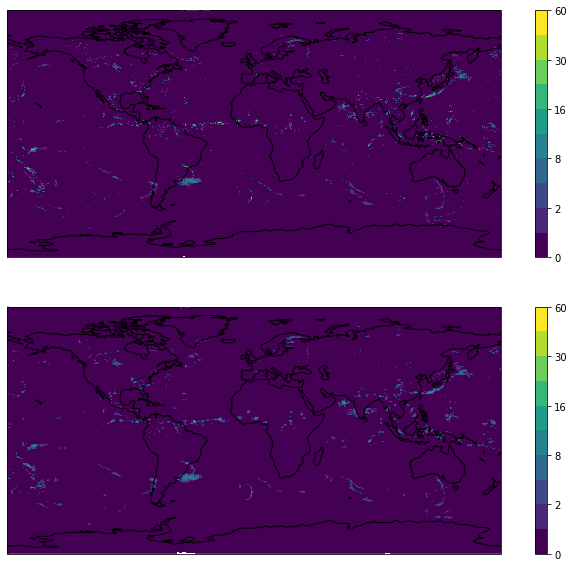

In [15]:
plot_imerg_n216imerg(imerg, n216imerg)

In [16]:
imerg.indexes

/home/users/mmuetz/miniconda3/envs/mcs_prime_env/lib/python3.10/site-packages/xarray/coding/times.py:351: FutureWarning: Index.ravel returning ndarray is deprecated; in a future version this will return a view on self.
  sample = dates.ravel()[0]


latitude: Float64Index([-89.94999694824219,  -89.8499984741211,             -89.75,
                         -89.6500015258789, -89.54999542236328, -89.44999694824219,
                         -89.3499984741211,             -89.25,  -89.1500015258789,
                        -89.04999542236328,
                        ...
                         89.04999542236328,   89.1500015258789,              89.25,
                          89.3499984741211,  89.44999694824219,  89.54999542236328,
                          89.6500015258789,              89.75,   89.8499984741211,
                         89.94999694824219],
                       dtype='float64', name='latitude', length=1800)
longitude: Float64Index([ -179.9499969482422, -179.85000610351562,             -179.75,
                         -179.64999389648438,  -179.5500030517578,  -179.4499969482422,
                         -179.34999084472656,             -179.25, -179.14999389648438,
                          -179.0500030517578,

In [17]:
n216imerg.indexes

time: CFTimeIndex([2020-07-01 00:00:00],
                  dtype='object', length=1, calendar='julian', freq=None)

In [18]:
# OK, this is weird. After regridding, n216imerg does not have indices on lat/lon, which means you can't call .sel on these dims.
# Save it and open it and you can though!
n216imerg.to_netcdf('n216imerg.nc')

In [19]:
n216imerg2 = xr.open_dataset('n216imerg.nc')

In [20]:
n216imerg2.sel(latitude=slice(-45, 50))

<xarray.Dataset>
Dimensions:        (time: 1, latitude: 171, longitude: 432)
Coordinates:
  * time           (time) object 2020-07-01 00:00:00
  * longitude      (longitude) float64 0.4167 1.25 2.083 ... 357.9 358.7 359.6
  * latitude       (latitude) float64 -44.72 -44.17 -43.61 ... 48.61 49.17 49.72
Data variables:
    precipitation  (time, latitude, longitude) float32 ...
Attributes:
    regrid_method:  conservative

imerg mean:     0.61833537
n216imerg mean: 0.6183401


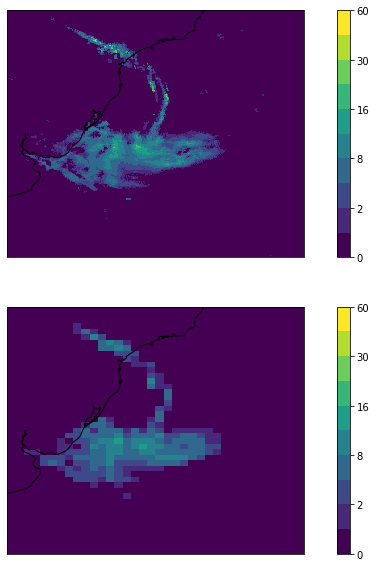

In [21]:
plot_imerg_n216imerg(imerg.sel(latitude=slice(-45, -20), longitude=slice(-60, -30)), n216imerg2.sel(latitude=slice(-45, -20), longitude=slice(300, 330)))

In [22]:
e5tcwv_path = cu.era5_sfc_fmtp('tcwv', t.year, t.month, t.day, t.hour)

In [23]:
e5tcwv_path.exists()

True

In [24]:
e5tcwv = xr.open_dataset(e5tcwv_path)

In [28]:
e5tcwv_bounds = e5tcwv.cf.add_bounds(['latitude', 'longitude'])

In [30]:
e5regridder = xe.Regridder(e5tcwv_bounds, n216ds_bounds, method='conservative', periodic=True)

/home/users/mmuetz/miniconda3/envs/mcs_prime_env/lib/python3.10/site-packages/xesmf/backend.py:53: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


In [35]:
n216e5tcwv = e5regridder(e5tcwv)
n216e5tcwv.to_netcdf('n216e5tcwv.nc')
n216e5tcwv = xr.open_dataset('n216e5tcwv.nc')

In [36]:
def plot_e5_n216e5(e5, n216e5, **sel):
    e5 = e5.sel(**sel)
    n216e5 = n216e5.sel(**sel)
    fig, axes = plt.subplots(2, 1, figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})
    norm = mpl.colors.BoundaryNorm(np.arange(0, 90, 10), 256)
    im = axes[0].pcolormesh(e5.longitude, e5.latitude, e5[0], norm=norm)
    plt.colorbar(im, ax=axes[0])
    im = axes[1].pcolormesh(n216e5.longitude, n216e5.latitude, n216e5[0], norm=norm)
    plt.colorbar(im, ax=axes[1])
    axes[0].coastlines()
    axes[1].coastlines()
    print('e5 mean:    ', np.mean(e5.values))
    print('n216e5 mean:', np.mean(e5.values))

e5 mean:     53.958153
n216e5 mean: 53.958153


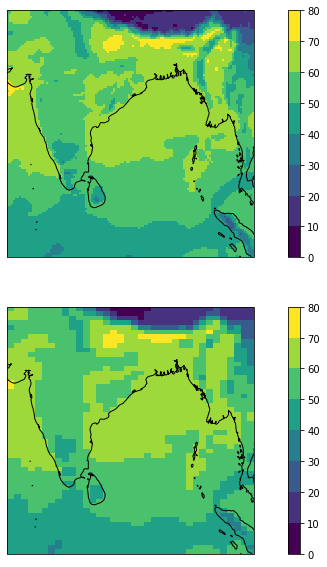

In [40]:
plot_e5_n216e5(
    e5tcwv.tcwv.sel(longitude=slice(70, 100), latitude=slice(30, 0)), 
    n216e5tcwv.tcwv.sel(longitude=slice(70, 100), latitude=slice(0, 30))
)